In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [2]:
df = pd.read_csv("../data/processed/tcs_stock_data_cleaned.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

print(df.shape)
df.head()

(1975, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2018-01-01,1341.150024,1347.400024,1317.500000,1322.800049,1351760
2018-01-02,1330.000000,1334.800049,1310.099976,1315.599976,1920290
2018-01-03,1316.000000,1334.500000,1315.599976,1319.324951,1257120
2018-01-04,1325.000000,1331.000000,1320.000000,1328.550049,913082
2018-01-05,1325.000000,1349.750000,1325.000000,1344.599976,1153706


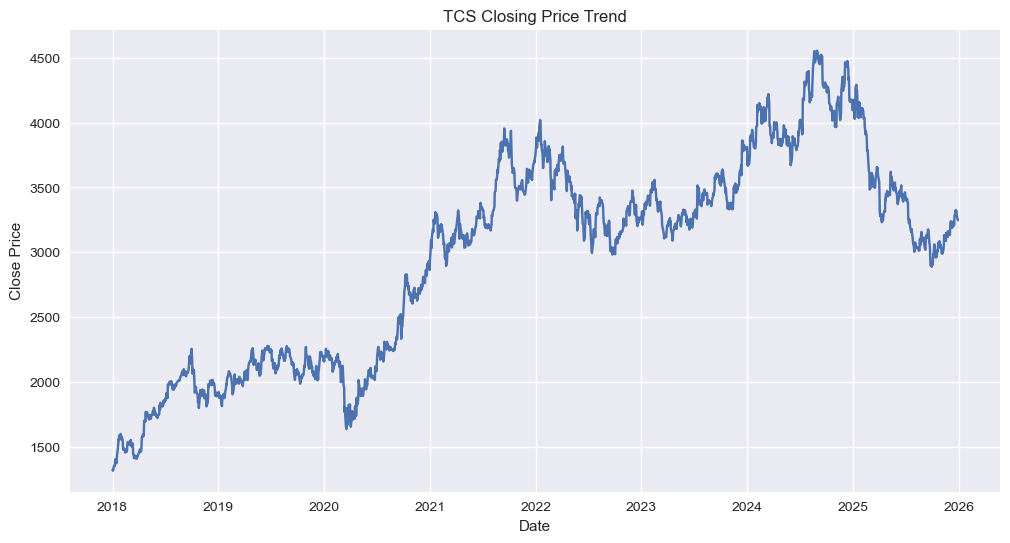

In [3]:
plt.figure(figsize=(12,6))

plt.plot(df["Close"])

plt.title("TCS Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

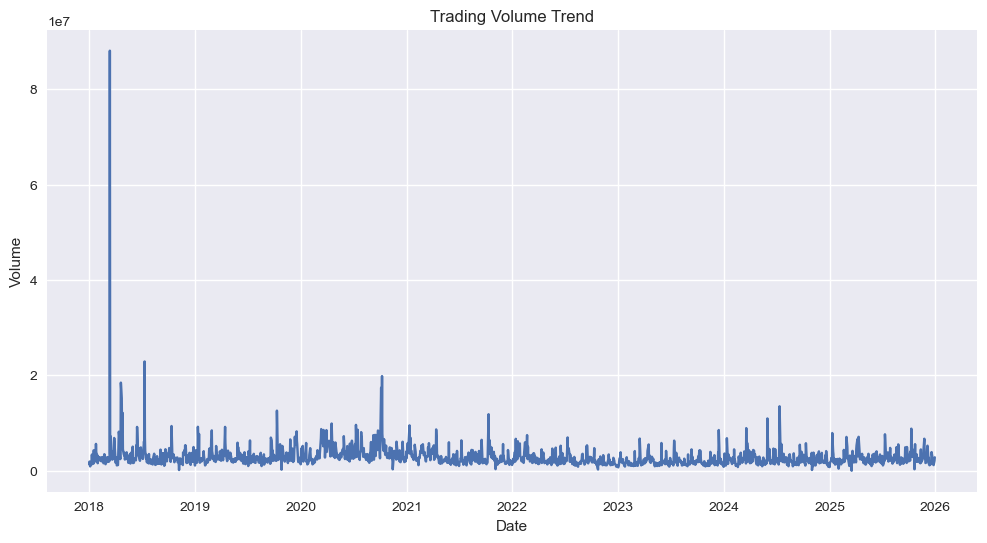

In [4]:
plt.figure(figsize=(12,6))

plt.plot(df["Volume"])

plt.title("Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

In [5]:
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

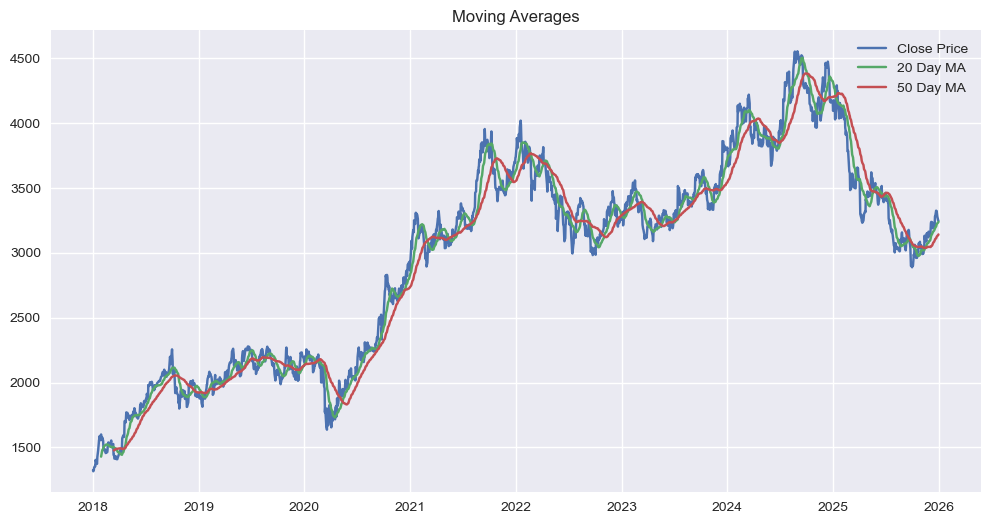

In [6]:
plt.figure(figsize=(12,6))

plt.plot(df["Close"], label="Close Price")
plt.plot(df["MA20"], label="20 Day MA")
plt.plot(df["MA50"], label="50 Day MA")

plt.title("Moving Averages")
plt.legend()

plt.show()

In [7]:
df["Daily_Return"] = df["Close"].pct_change()

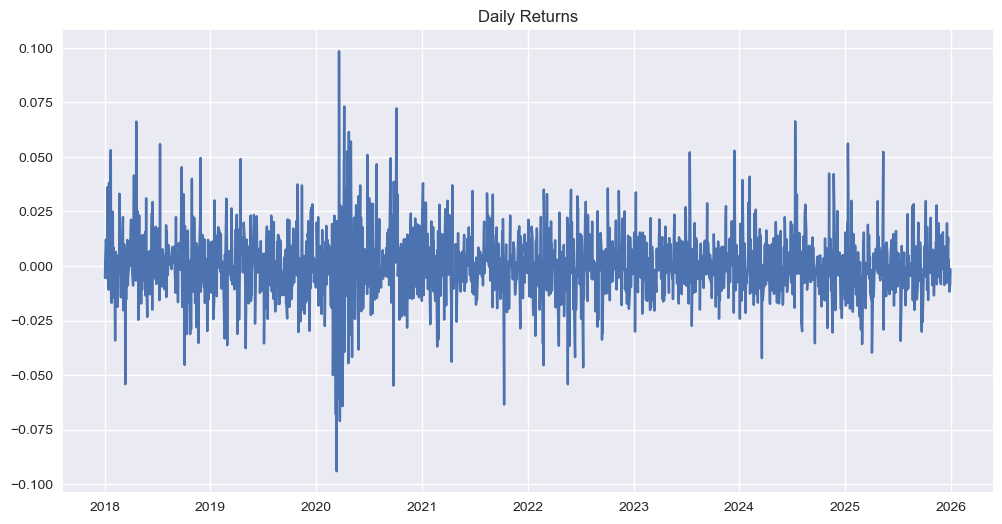

In [8]:
plt.figure(figsize=(12,6))

plt.plot(df["Daily_Return"])

plt.title("Daily Returns")

plt.show()

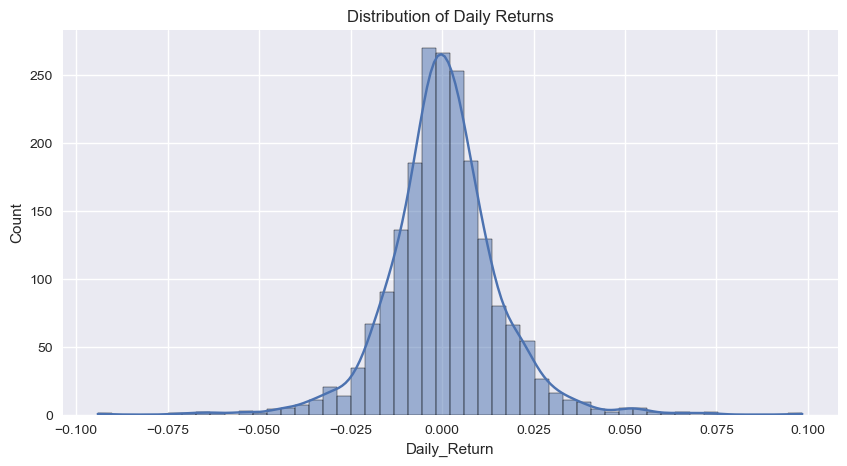

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(df["Daily_Return"].dropna(), bins=50, kde=True)

plt.title("Distribution of Daily Returns")

plt.show()

In [10]:
df["Volatility"] = df["Daily_Return"].rolling(window=20).std()

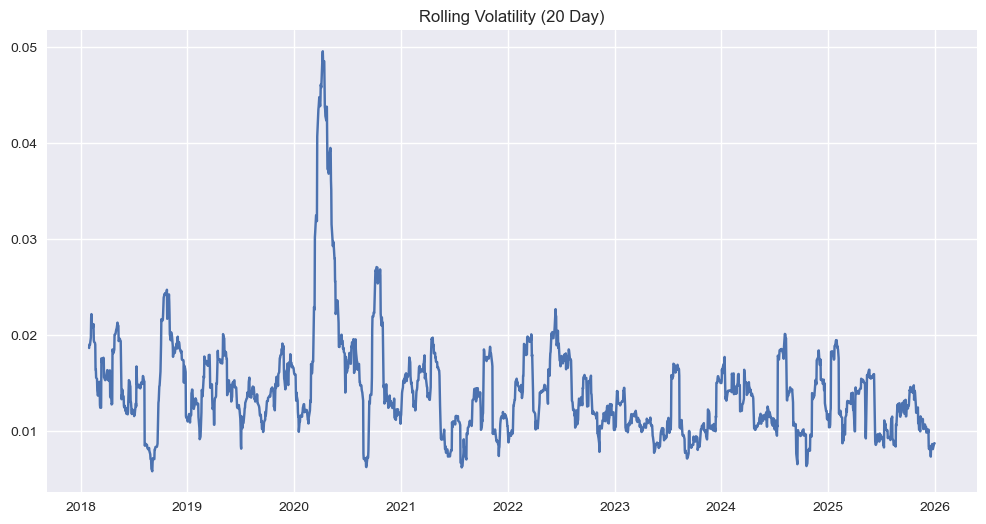

In [11]:
plt.figure(figsize=(12,6))

plt.plot(df["Volatility"])

plt.title("Rolling Volatility (20 Day)")

plt.show()

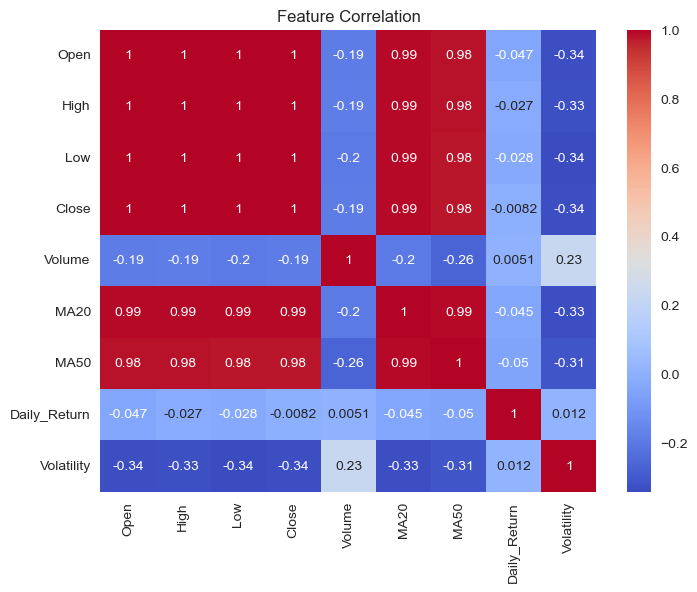

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

In [13]:
df.to_csv("../data/processed/tcs_stock_data_eda.csv")